<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">

<h style="color:#003366; font-size:48px; margin-bottom:10px;">
  🐍  <b>Sprint 11</b>  📊
</h>



  <h2 style="color:#C9B037; font-size:42px; margin-top:0;">
    Data Visualization,
    Python & Power BI
  </h2>

</div>
<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:65%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">

<h2 style="color:#003366;">Description :</h2>

<p style="color:#777777;">
This practice integrates the use of Python with the Pandas, Matplotlib, Seaborn, or Plotly libraries, as well as its integration with Power BI.<br>
You will work through the entire process from connecting to MySQL, creating advanced visualizations in Python,<br>
and finally incorporating these visualizations into a dynamic report in Power BI
</p>



<p style="color:#CC4444; font-style:italic;">
For this Sprint, all documentation and code will be written entirely in English to ensure consistency and technical clarity.
</p>

</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:65%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">

<h2><span style="color:#003366">🐬 MySQL on Python 🐬 </span></h2>

<h2 style="color:#C9B037;">Level 1</h2>


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<h3><span style="color:#003366">Exercise 1: <br></span></h3>
<p style="color:#777777;">
Connect Python with MySQL Workbench and load the data from your Sprint 4 database to use it throughout all the exercises.
</p>

</div>




In [177]:
# Import all libraries needed for the sprint:


# Data manipulation and numerical computation

import numpy as np
import pandas as pd
from datetime import datetime, date, timedelta
import random
import string
import os

# Visualization

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# To connect MySql 

import mysql.connector
from mysql.connector import Error


In [178]:
# Connection with MySQL and creation of the database dictionary

try:
    connection = mysql.connector.connect(host="localhost",
                                         database="Transfer_Analytics",
                                         user="root",
                                         password="ContraseñaMySql890@")

    if connection.is_connected():
        print("connection complete:", connection)

        cursor = connection.cursor()
        print("Cursor ready to work")

        cursor.execute("SHOW TABLES")
        tables = cursor.fetchall()

        dics_tables = {}

        for table in tables:
            name_tab = table[0]
            df = pd.read_sql(f"SELECT * FROM {name_tab}", connection)
            dics_tables[name_tab] = df
        
        print("Dict created!!!")

except Error:
    print("Error to connect MySQL!!!")

connection complete: <mysql.connector.connection_cext.CMySQLConnection object at 0x000001BAAD252490>
Cursor ready to work


C:\Users\eirad\AppData\Local\Temp\ipykernel_29436\1569175920.py:22: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



Dict created!!!


In [179]:
# Checking the tables names

dics_tables.keys()

dict_keys(['american_users', 'cards_analysis', 'companies', 'credit_cards', 'european_users', 'products', 'transactions', 'transactions_details', 'users'])

In [180]:
# Checking NaN

print("Number of NaN for each table:")
print("-" * 30)

for table_name, df in dics_tables.items():
    total_nulls = df.isna().sum().sum()
    print(f"{table_name}: {total_nulls}")
    
print("-" * 30)

Number of NaN for each table:
------------------------------
american_users: 0
cards_analysis: 0
companies: 0
credit_cards: 0
european_users: 0
products: 0
transactions: 0
transactions_details: 0
users: 0
------------------------------


In [181]:
# Deleting unnecessary tables

del dics_tables["american_users"]
del dics_tables["european_users"]

dics_tables.keys()

dict_keys(['cards_analysis', 'companies', 'credit_cards', 'products', 'transactions', 'transactions_details', 'users'])

In [182]:
# Checking tables

for table in dics_tables:
    table = display(dics_tables[table].iloc[:10].style\
                    .set_properties(**{'border': '1px solid white', 'text-align': 'center'}))


,card_id,status_cards
0,CcS-4857,ACTIVE
1,CcS-4858,ACTIVE
2,CcS-4859,ACTIVE
3,CcS-4860,ACTIVE
4,CcS-4861,ACTIVE
5,CcS-4862,ACTIVE
6,CcS-4863,ACTIVE
7,CcS-4864,ACTIVE
8,CcS-4865,ACTIVE
9,CcS-4866,ACTIVE


,id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings
5,b-2242,Donec Ltd,01 25 51 37 37,at.iaculis@hotmail.couk,Norway,https://nytimes.com/user/110
6,b-2246,Sed Nunc Ltd,02 62 64 73 48,nibh@yahoo.org,United Kingdom,https://cnn.com/one
7,b-2250,Amet Nulla Donec Corporation,07 15 25 14 74,mattis.integer.eu@protonmail.net,Italy,https://netflix.com/sub/cars
8,b-2254,Nascetur Ridiculus Mus Inc.,06 26 87 61 84,suspendisse.dui@icloud.net,United States,https://ebay.com/sub
9,b-2258,Vestibulum Lorem PC,02 02 87 33 40,aenean.massa.integer@aol.net,Belgium,https://pinterest.com/sub/cars


,id,user_id,iban,pan,pin,cvv,track1,track2,expiring_date
0,CcS-4857,276,XX4857591835292505850771,2314242385113924,1819,467,%B2314242385113924^LWCBUDLWCBUD^2206000000000000000?,%B2314242385113924=2410101518363164?,2025-09-27
1,CcS-4858,277,XX8581768137002436094025,6582720299715533,3964,817,%B6582720299715533^TIQMVITIQMVI^2404000000000000000?,%B6582720299715533=2411101104546272?,2028-12-28
2,CcS-4859,278,XX7826930491423553609370,8861684536289642,4983,277,%B8861684536289642^COFBGDCOFBGD^2802000000000000000?,%B8861684536289642=2502101761665371?,2026-11-26
3,CcS-4860,279,XX5559590368835304645299,2481155515498459,6876,661,%B2481155515498459^TIUJTUTIUJTU^3104000000000000000?,%B2481155515498459=2602101514414395?,2027-07-27
4,CcS-4861,280,XX2035182877195191627307,1308930301149557,5710,398,%B1308930301149557^HPOBNZHPOBNZ^3301000000000000000?,%B1308930301149557=2805101751305028?,2026-04-25
5,CcS-4862,281,XX4774721462463645409758,6715617009807829,4042,174,%B6715617009807829^LDMWTDLDMWTD^3308000000000000000?,%B6715617009807829=2210101702370428?,2026-11-27
6,CcS-4863,282,XX1476829664245046207111,3140879819451394,5969,449,%B3140879819451394^OXXJODOXXJOD^2309000000000000000?,%B3140879819451394=3210101158648599?,2029-12-27
7,CcS-4864,283,XX8380298893385731196159,5793672133649114,8481,139,%B5793672133649114^NHWBYRNHWBYR^3002000000000000000?,%B5793672133649114=2306101806367101?,2026-02-28
8,CcS-4865,284,XX7085078596101025280599,5101552687251312,7847,903,%B5101552687251312^MJODHKMJODHK^3302000000000000000?,%B5101552687251312=3010101664862710?,2028-11-25
9,CcS-4866,285,XX4792859188206596406839,8080768801072613,9271,961,%B8080768801072613^MEBGOZMEBGOZ^3210000000000000000?,%B8080768801072613=2810101715885695?,2025-02-28


,id,product_name,price_$,colour,weight,warehouse_id
0,1,Direwolf Stannis,161.110000,#7c7c7c,1.000000,WH-4
1,10,Karstark Dorne,119.520000,#f4f4f4,2.400000,WH--5
2,100,south duel,40.430000,#6d6d6d,3.000000,WH--95
3,11,Karstark Dorne,49.700000,#141414,2.700000,WH--6
4,12,duel Direwolf,181.600000,#a8a8a8,2.100000,WH--7
5,13,palpatine chewbacca,139.590000,#2b2b2b,1.000000,WH--8
6,14,Direwolf,147.530000,#c4c4c4,2.000000,WH--9
7,15,Stannis warden,194.290000,#dbdbdb,1.500000,WH--10
8,16,the duel warden,180.910000,#666666,3.000000,WH--11
9,17,skywalker ewok sith,91.890000,#7c7c7c,3.200000,WH--12


,id,card_id,company_id,timestamp,amount,declined,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.430000,0,4713,46.199900,1.435540
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.630000,0,438,41.597200,12.221800
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.010000,0,2118,29.757300,-95.379600
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.600000,0,2115,53.548900,-113.503000
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.910000,0,3025,52.208400,5.690810
5,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,294.590000,0,215,53.553500,-113.499000
6,0009A151-9BCF-4E31-9053-A468FF77FAAB,CcS-7509,b-2546,2023-12-31 00:06:36,383.630000,0,2928,51.936200,5.342650
7,0009D494-6245-4DF9-955D-2C084191CFFB,CcS-8483,b-2526,2017-07-18 07:52:02,197.800000,0,3902,45.492000,-73.570600
8,000A1DEC-CDB6-4AB2-A619-71DAB8D4A262,CcS-6467,b-2558,2018-09-08 05:29:58,339.940000,0,1886,55.742500,-3.300090
9,000A1E64-1414-40B0-9D92-5678A4D958E2,CcS-5966,b-2550,2022-09-17 04:02:19,369.710000,0,1385,52.082100,5.284240


,product_id,transaction_id
0,1,001A60EA-DC9C-4E5A-9460-6628B100E7E1
1,1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48
2,1,00342381-503D-422D-85AB-F2D4FFAAD4C7
3,1,004C0A80-E537-46D8-BE44-343D2176DF15
4,1,004D1DB5-B2CB-4460-98B6-31C42CA96E5F
5,1,0062599C-0A1F-4405-AD55-45E20043B551
6,1,007B1297-C3ED-4966-802C-68FE106AD25C
7,1,007EA15D-AA1F-4FB3-9483-7D055E99CEC0
8,1,009679D1-1849-47C1-98E8-8F6C0EA5DF32
9,1,0096A25B-BDAD-47DE-85AD-BA3741BE7736


,id,name,surname,phone,email,birth_date,country,city,postal_code,address,user_region
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,American
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,1984-04-30,United States,San Jose,95101,P.O. Box 773,American
2,100,Melodie,Mclean,1-677-221-7152,risus.varius@google.ca,1989-09-15,United States,San Jose,95101,Ap #644-8492 Sagittis St.,American
3,1000,Amkjrv,Qbulrxbp,+48-258-9936,amkjrv.qbulrxbp@example.com,1970-05-17,Germany,Stuttgart,70173,215 Qbulrxbp St,European
4,1001,Nfvrlb,Oydaiwbg,+94-121-2522,nfvrlb.oydaiwbg@example.com,1994-03-04,Germany,Cologne,50667,121 Oydaiwbg St,European
5,1002,Ijbfmd,Jbddzhvp,+70-120-3668,ijbfmd.jbddzhvp@example.com,2001-09-27,Germany,Munich,80331,412 Jbddzhvp St,European
6,1003,Uyciig,Sfbdymzj,+58-123-6968,uyciig.sfbdymzj@example.com,1981-01-20,Germany,Stuttgart,70173,735 Sfbdymzj St,European
7,1004,Yjqurq,Ojizvgqi,+77-944-2340,yjqurq.ojizvgqi@example.com,1954-07-27,Germany,Munich,80331,685 Ojizvgqi St,European
8,1005,Mnlqtu,Glofegwk,+54-801-2627,mnlqtu.glofegwk@example.com,1962-11-15,Portugal,Funchal,9000-001,8 Glofegwk St,European
9,1006,Rbkocq,Swkmynuj,+38-186-8580,rbkocq.swkmynuj@example.com,1989-12-02,United States,New York,10001,567 Swkmynuj St,American


In [183]:
# Cheking info tables

for table in dics_tables:
    print(dics_tables[table].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   card_id       5000 non-null   object
 1   status_cards  5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            100 non-null    object
 1   company_name  100 non-null    object
 2   phone         100 non-null    object
 3   email         100 non-null    object
 4   country       100 non-null    object
 5   website       100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0  

<div style="text-align:center;">


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<h3><span style="color:#003366">News columns:<br></span></h3>
<p style="color:#777777;">
Creating new columns in the users products and transactions tables, where I will calculate ranges based on quintiles.
</p>

</p>

</div>

In [184]:
# Calculate "age" 

def calculo_edat(raw):

    today = datetime.now()

    age = today.year - raw.year

    if (today.month,raw.month) < (today.day,raw.month):
        age -= 1

    return age


dics_tables["users"]["age"] = dics_tables["users"]["birth_date"].apply(calculo_edat)

In [185]:
# Calculate age_range

def age_range(age):

    if age <= 31:
        return "20-31"
    elif age <= 41:
        return "32-41"
    elif age <= 53:
        return "42-53"
    elif age <= 65:
        return "54-65"
    else:
        return "66-76"
    
dics_tables["users"]["age_range"] = dics_tables["users"]["age"].apply(age_range)

In [186]:
# Creating "full_name"

dics_tables["users"]["full_name"] = dics_tables["users"]["name"] + " " + dics_tables["users"]["surname"]

In [187]:
# Calculate "price_range"

def price_range(price):

    if price <= 40.29:
        return "1.low"
    elif price <= 78.28:
        return "2.low-medium"
    elif price <= 127.23:
        return "3.medium"
    elif price <= 167.23:
        return "4.medium-high"
    else:
        return "5.high"
    
dics_tables["products"]["price_range"] = dics_tables["products"]["price_$"].apply(price_range)

In [188]:
# Calculate "month_name"

dics_tables["transactions"]["month_name"] = dics_tables["transactions"]["timestamp"].dt.month_name()

# Calculate "year"

dics_tables["transactions"]["year"] = dics_tables["transactions"]["timestamp"].dt.year

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);

<div style="text-align:center;">

<h2><span style="color:#003366">🎨 Tasks Development: 🎨 </span></h2>

<h3 style="color:#C9B037">Progressive Visualization Approach</h3>

<p style="color:#777777;">
I will develop a series of visualizations organized by increasing levels of complexity.<br>
The process will begin with basic, entry‑level charts and progress toward more advanced analytical graphics.<br>
Throughout all levels, I will ensure that the information remains fully understandable and with a clear visual interpretation.
</p>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<h3><span style="color:#003366">Exercise 2: <br></span></h3>
<font color="#777777">

For each item, create an appropriate visualization based on the specified variables.<br>
Interpret the results according to your dataset.<br><br>

<span style="color:#C94F4F;">
Remember : Always consider the method you will use and include the variables required for the visualization function you intend to apply:<br>
</span>


• One numerical variable.<br>
• One categorical variable.<br>
• One categorical variable and one numerical variable.<br>
• Two categorical variables.<br>
• Two numerical variables.<br>
• Three combined variables.<br>
• Create a Pairplot.<br>

</font>

</div>




<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

### One numerical variable ###
</span>

</div>

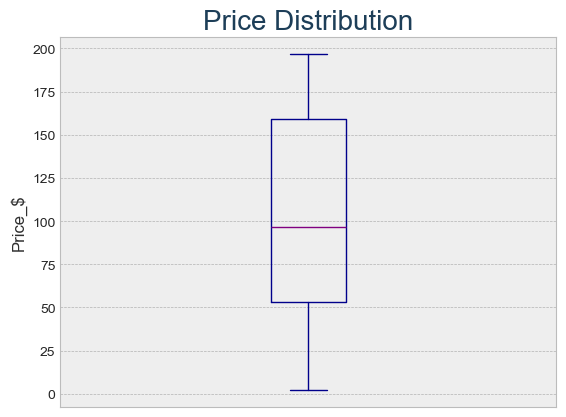

In [189]:
# One numerical variable , using "products" table and "price_$" column:

df_a = dics_tables["products"][["price_$"]]

# Visualize price distribution with a boxplot
plt.style.use('bmh')

graphic_a = df_a.plot.box(title="Price Distribution",color = "darkblue",medianprops=dict(color="purple"))

plt.xticks([])
plt.ylabel("Price_$")

# Set colors

graphic_a.set_title("Price Distribution", fontsize=20, color="#1d3e58")           
graphic_a.yaxis.label.set_color("#2f2f2f")    


plt.show()


<div style="text-align:center;">

<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This chart illustrates a stable pricing strategy with values ranging from $0 to $200.<br>
The median price is approximately $100, and the lack of outliers indicates consistent product valuation across the entire catalog.<br>
Most items are concentrated within the $50 to $160 interquartile range.<br>
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

### One categorical variable ###

</span>

</div>

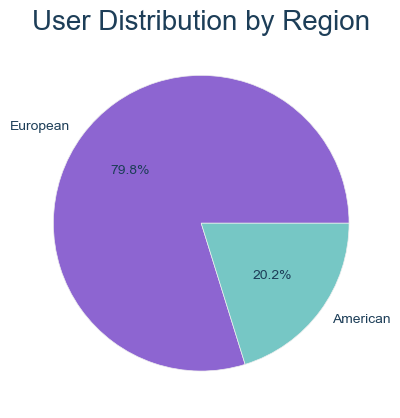

In [190]:
# One categorical variable , using "users" table and column "user_region":

df_b = dics_tables["users"]["user_region"]

# Visualizing users distribution by region (pie)


graphic_b = df_b.value_counts().plot.pie(autopct='%1.1f%%',title="User Distribution by Region", ylabel="",
                                         colors = ["#8D65D1", "#76C7C5"],textprops={'color': "#1d3e58"})

graphic_b.set_title("User Distribution by Region", fontsize=20, color="#1d3e58")


plt.show()

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
The regional analysis shows that the European market is the dominant segment, accounting for 79.8% of the user base.<br>
American users represent a significant but smaller portion at 20.2%.<br>
This highlights a heavy geographical concentration of the business within the European territory.
</font>
</div>
<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

### One categorical and one numerical ###
</span>

</div>

In [191]:
# One categorical variable and one numerical variable, using "transactions" table:

df_c = pd.merge( dics_tables["transactions"], dics_tables["users"] , left_on= "user_id" , right_on= "id",suffixes= ("_trans","_user") )

df_c = df_c[df_c["declined"] == 0]

df_c = df_c[["user_id","full_name","amount"]].groupby(["user_id","full_name"]).mean("amount").round(0)

df_c = df_c.sort_values("amount", ascending= False)

# Query to identify same average amount as the top 10

min = df_c.head(10)   

df_c = df_c[df_c["amount"] >= min["amount"].iloc[-1]]

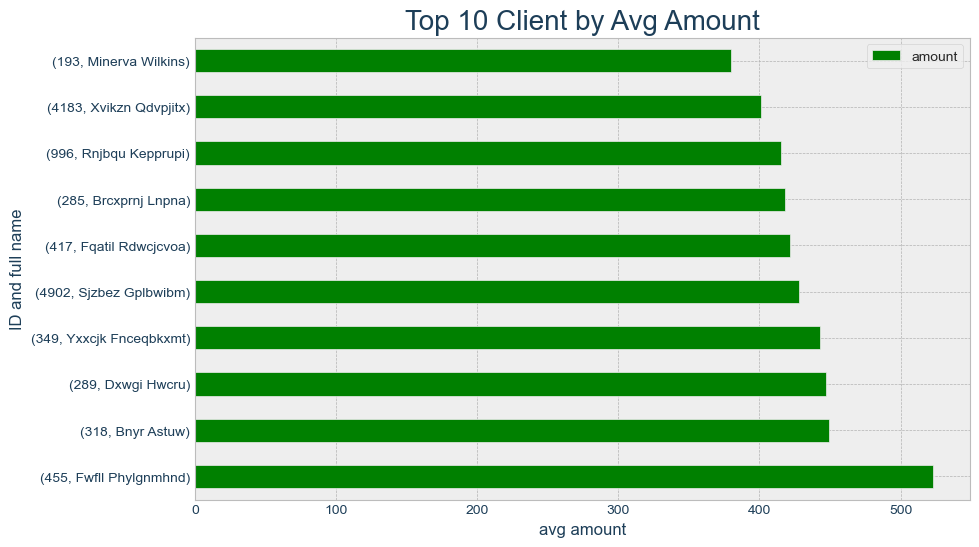

In [192]:
# Visualize the top 10 client by average amount 

graphic_c = df_c.plot.barh(figsize=(10,6),color="green",ylabel="ID and full name",xlabel="avg amount",
                           title="Top 10 Client by Avg Amount")

# Set colors 
plt.style.use('bmh')

graphic_c.set_title("Top 10 Client by Avg Amount", fontsize=20, color="#1d3e58")

graphic_c.yaxis.label.set_color("#1d3e58")
graphic_c.xaxis.label.set_color("#1d3e58")

graphic_c.tick_params(axis='both', colors="#1d3e58")

plt.show()

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This chart identifies the most valuable customers based on their average transaction size.<br> 
The top client, Fwfll Phylgnmhnd, leads with an average spend exceeding 500.<br> 
The remaining top ten maintain a consistent average between 400 and 500, showing a loyal group of high-spending individuals.
</font>
</div>
<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

### Two categorical variables ###
</span>

</div>

In [193]:
# Two categorical variables, using "users" table:

df_d = pd.crosstab(dics_tables["users"]["age_range"],dics_tables["users"]["country"]).transpose()

df_d = df_d.loc[df_d.sum(axis=1).sort_values(ascending=False).index]


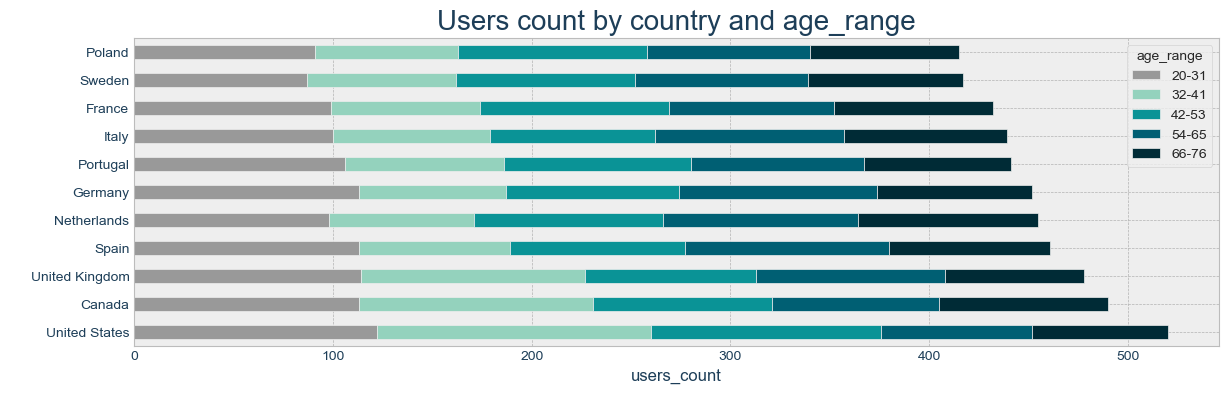

In [194]:
# Visualize user count by country and age_range
plt.style.use('bmh')

graphic_d = df_d.plot.barh(figsize =(14,4), stacked=True,color= ("#999999", "#94D2BD", "#0A9396", "#005F73", "#002B36"), 
                            ylabel = " ", xlabel = "users_count" , title="Users count by country and age_range")

# Set colors

graphic_d.set_title("Users count by country and age_range", fontsize=20, color="#1d3e58")

graphic_d.yaxis.label.set_color("#1d3e58")
graphic_d.xaxis.label.set_color("#1d3e58")

graphic_d.tick_params(axis='both', colors="#1d3e58")

plt.show()

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
The data reveals that the United States has the largest total user count, followed by Canada and the UK.<br>
Across all listed countries, the user base is remarkably well-balanced among five distinct age groups,<br> 
indicating that the product holds a broad demographic appeal.
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

### Two numerical variables ###
</span>

</div>

In [195]:
# Two numericals variables , using "products" and "transactions_details" tables:

prod = dics_tables["products"][["id","product_name","price_$","price_range"]]

declined_false = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]  

details = dics_tables["transactions_details"][dics_tables["transactions_details"]["transaction_id"].isin(declined_false["id"])]

details = details.groupby("product_id").count()

df_e = pd.merge(prod, details,left_on= "id",right_on="product_id", how="inner")

df_e = df_e.rename(columns={"transaction_id" : "quantity sold"})


In [196]:
# Visualize correlation between price and quantity sold (scatterplot - plotly)

graphic_e = px.scatter(df_e, x = "price_$" , y = "quantity sold" ,hover_data = ["product_name","price_range"], size = "price_$" ,trendline="ols", 
                       title= "Correlation between price and quantity sold" , color_discrete_sequence=["#1d3e58"])


graphic_e.update_layout(title={'x': 0.5,
                            'font': {'color': '#1d3e58','size': 28}},
                            font=dict(color="#1d3e58"))


graphic_e.show()

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This plot examines demand elasticity, showing a slight positive correlation between price and quantity sold.<br>
Contrary to typical expectations, higher prices do not appear to deter volume, as most products maintain a<br>
steady sales figure regardless of their price point.
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

###  Three combined variables ###
</span>

</div>

In [197]:
# Three combined variables , using "transactions" and "users" tables

df_f = pd.merge(dics_tables["transactions"],dics_tables["users"],left_on= "user_id", right_on="id")

df_f = df_f[df_f["declined"] == 0]

df_f = df_f.sort_values("timestamp",ascending= True)


<Axes: title={'center': 'Transaction amount by month and user region'}, xlabel=' ', ylabel='amount'>

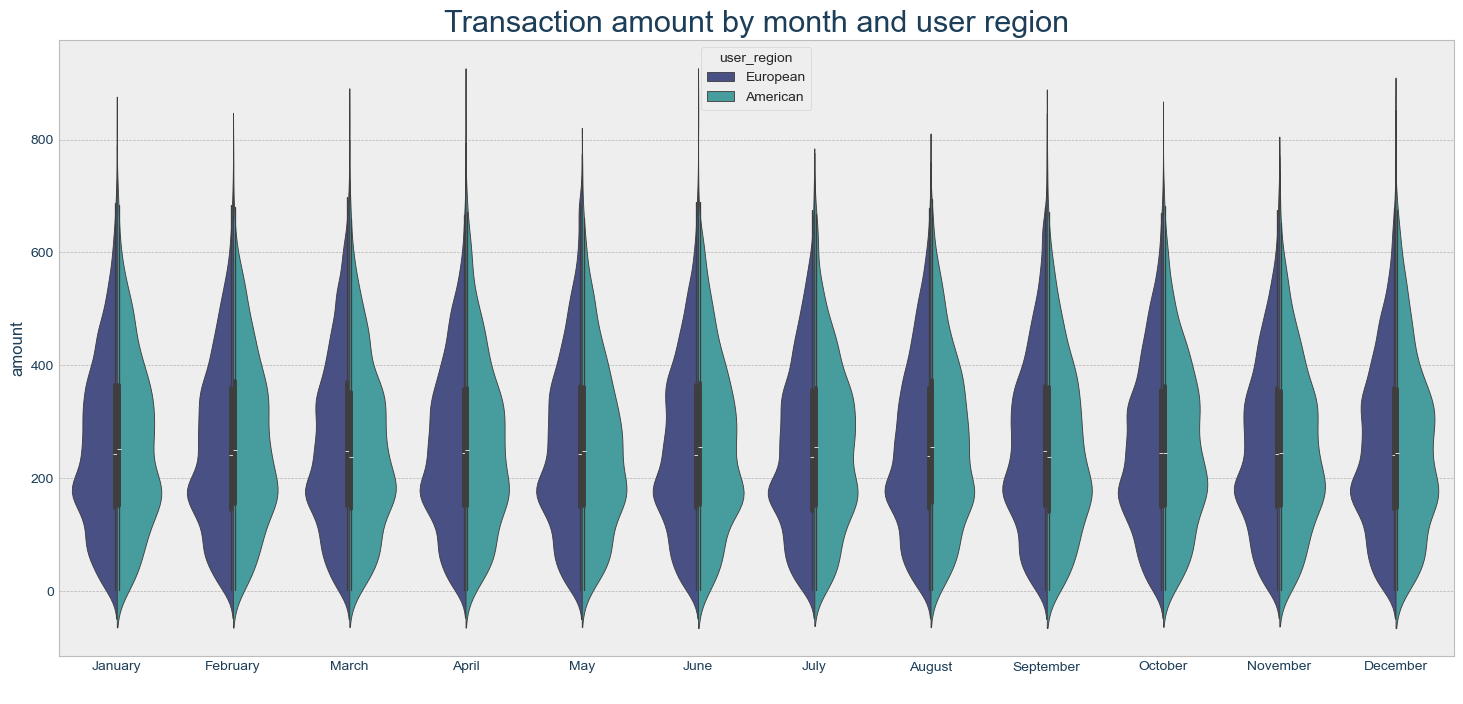

In [198]:
# Visualize transaction amount by month and user region (violin plot - seaborn) 

plt.style.use('bmh')

plt.figure(figsize=(18, 8))
plt.xlabel(" ")

graphic_f = sns.violinplot(df_f,x= "month_name" ,y= "amount", hue= "user_region",split= "user_region",palette= "mako")

# Set colors

graphic_f.set_title("Transaction amount by month and user region", fontsize=22, color="#1d3e58")

graphic_f.yaxis.label.set_color("#1d3e58")
graphic_f.xaxis.label.set_color("#1d3e58")

graphic_f.tick_params(axis='both', colors="#1d3e58")

graphic_f

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This visualization compares monthly transaction distributions between European and American users.<br>
Both markets exhibit nearly identical spending patterns throughout the year.<br> 
There is a consistent concentration of transaction values across both regions every month.
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<span style="color:#003366;">

### Create a Pairplot  ###
</span>

</div>

In [199]:
# Pairplot , using "transactions","companies" and "products" tables

# Sales by products

prod = dics_tables["products"]

declined_false = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]  # Transaction No declined!

details = dics_tables["transactions_details"][dics_tables["transactions_details"]["transaction_id"].isin(declined_false["id"])]

details_trans = pd.merge(details,dics_tables["transactions"],left_on="transaction_id",right_on="id")

details_trans = details_trans.groupby("product_id").agg( quantity_sold = ("product_id","count"), total_sales = ("amount","sum") )

df_g = pd.merge(prod, details_trans,left_on= "id",right_on="product_id", how="inner")

df_g = df_g.sort_values("price_range",ascending=True)

df_g

,id,product_name,price_$,colour,weight,warehouse_id,price_range,quantity_sold,total_sales
48,52,riverlands the duel,31.52,#727272,3.0,WH--47,1.low,2642,641192.57
80,81,the duel,15.87,#7f7f7f,1.2,WH--76,1.low,2465,554409.12
78,8,Winterfell,32.37,#383838,1.4,WH--3,1.low,2495,597069.91
81,82,kingsblood Littlefinger the,12.45,#545454,2.4,WH--77,1.low,2558,559942.45
82,83,duel tourney,26.51,#cccccc,2.7,WH--78,1.low,2477,587945.21
...,...,...,...,...,...,...,...,...,...
23,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2,5.high,2520,955331.49
26,32,north,178.28,#0f0f0f,1.4,WH--27,5.high,2559,981007.87
33,39,warden,196.65,#a0a0a0,1.5,WH--34,5.high,2570,1027849.42
76,78,Karstark warden,178.85,#919191,0.8,WH--73,5.high,2534,973510.34


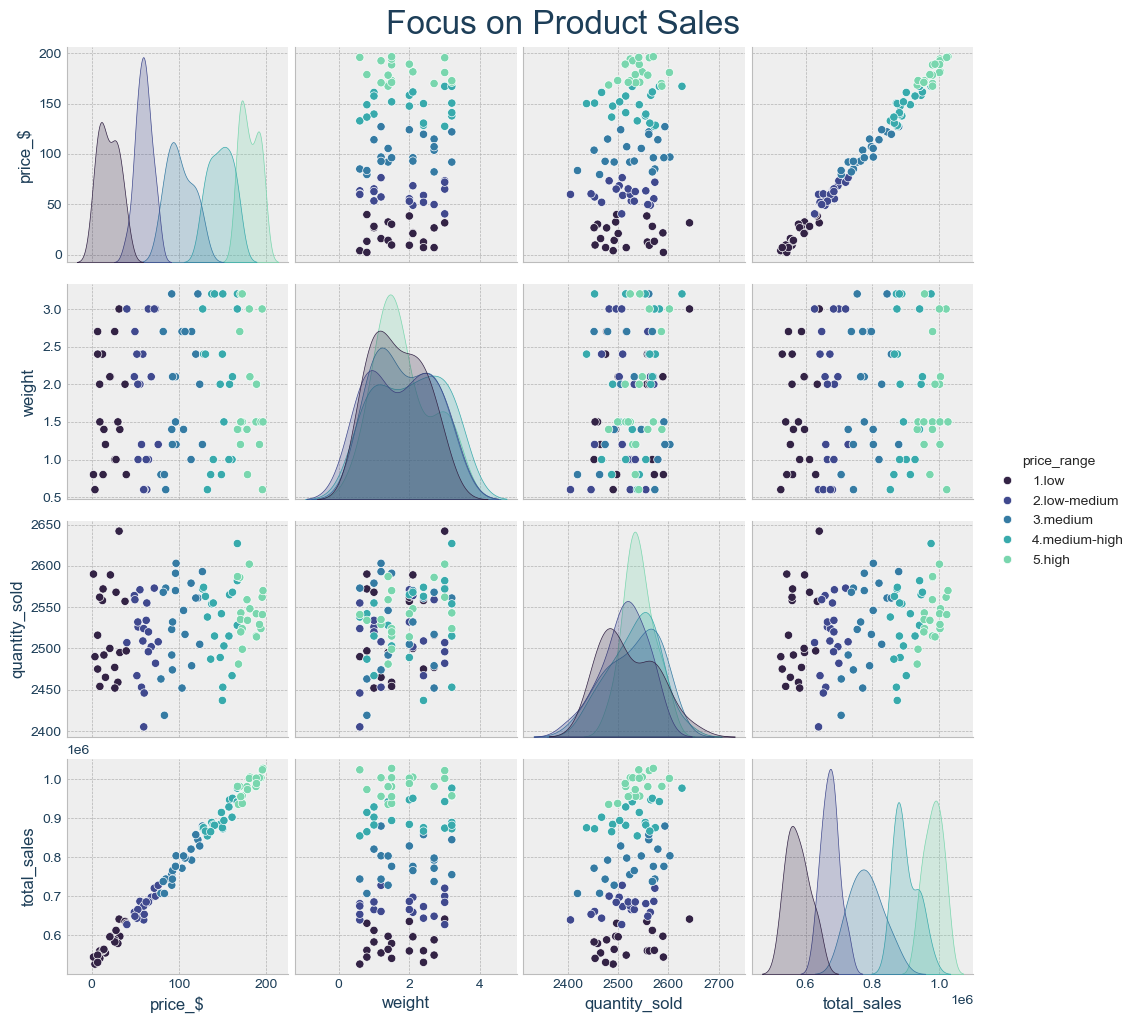

In [200]:
# Visualize : Focus on product sales (pairplot - seaborn)

plt.style.use('bmh')

graphic_g = sns.pairplot(df_g,hue="price_range",diag_kind="kde", corner=False, palette="mako" )       

graphic_g.fig.suptitle("Focus on Product Sales",fontsize=24,y=1.02,  color="#1d3e58")


for ax in graphic_g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_color("#1d3e58")
        ax.yaxis.label.set_color("#1d3e58")
        ax.tick_params(axis='both', colors="#1d3e58")

plt.show()


<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
The matrix highlights that total sales are primarily driven by product price, showing a strong linear correlation between the due.<br>
The segmentation into five price tiers demonstrates that higher-priced products are the main contributors to overall revenue without negatively impacting sales volume.
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);

<div style="text-align:center;">
    

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>


<div style="text-align:center;">
    

<h2 style="color:#C9B037;">Level 2</h2>


<h3><span style="color:#003366">Exercise 1: <br></span></h3>
<p style="color:#777777;">
1. Represent the correlation of some variables and interpret the results according to your data.
</p>

</div>



In [201]:
# Correlation of some variables, using "users" and "transactions" tables

df_h = pd.merge(dics_tables["users"],dics_tables["transactions"], how="left" ,left_on="id",right_on="user_id",suffixes=("_user","_trans"))

df_h = df_h[["user_id","full_name","amount","age","age_range"]].groupby("user_id").agg(full_name = ("full_name","first") , total_amount = ("amount","sum"), avg_amount = ( "amount","mean"), age = ("age","min"),age_range = ("age_range","first")).round(2)

df_h = df_h.sort_values("age_range",ascending=True)

In [202]:
# Visualaze correlation between total amount and age users

graphic_h = px.scatter(df_h, x = "total_amount" , y = "age" ,size = "avg_amount" , color = "age_range", hover_name = "full_name", trendline="ols",
                       color_discrete_sequence = ["#999999", "#94D2BD", "#0A9396", "#005F73", "#002B36"], title= "Users : Correlation between total amount and age ")

graphic_h.update_layout( width=1400, height=800)

graphic_h.update_layout(title_font_color="#1d3e58",
                        title={"text": "Users : Correlation between total amount and age ","x": 0.5,"xanchor": "center",
                             "yanchor": "top","font": {"size": 32,"color": "#1d3e58" }},
                             
                             legend=dict(font=dict(size=17, color="#1d3e58"),
                                                  title_font=dict(size=22, color="#1d3e58")))

graphic_h.show()

<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This scatter plot examines the relationship between total spending and user age across five demographic groups.<br>
The data shows that while most users spend under $15,000, high-value outliers exist across all age ranges.<br>
The relatively flat regression lines suggest that age is not a primary driver of total spending,<br>
indicating consistent purchasing behavior throughout the user life cycle.
</font>
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<h3><span style="color:#003366">Exercise 2: <br></span></h3>
<p style="color:#777777;">
2. Implement a Jointplot to explore the relationship between two variables and interpret the results according to your data.
</p>

</div>

In [203]:
# Jointplot , Correlation between two variables more some extra details , using "transactions" and "users" tables 

''' Utilizing Plotly Express instead of Seaborn's jointplot to leverage interactive marginal distributions and built-in OLS trendline analysis '''

df_i = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]

df_i = pd.merge( df_i , dics_tables["users"] , left_on= "user_id" , right_on= "id" , suffixes= ("_trans","_user"))

df_i = df_i.groupby("city").agg(avg_trans = ("amount","mean"), max_trans = ("amount","max") ,tot_trans = ("amount","sum"), count_users = ("user_id","count")).round(2)


In [204]:
# Visualize the correlation between average and total transaction amounts by city

graphic_i = px.scatter(df_i.reset_index(), x="avg_trans", y="tot_trans", marginal_x="histogram", marginal_y="histogram",trendline="ols",
                     size = "count_users" , size_max=30, hover_name="city", hover_data={"avg_trans": True, "tot_trans": True}, color="max_trans")

# Adjust figure size
graphic_i.update_layout( width=1200, height=800)

# Configure title
graphic_i.update_layout(title={"text": "Total vs Average Transaction Amount", "x": 0.5,"xanchor": "center",
                             "yanchor": "top","font": {"size": 32,"color": "#FFFFFF" }})

# Apply colors
graphic_i.update_layout(coloraxis_colorscale="Ice")

graphic_i.update_layout(paper_bgcolor="#1a1a1a", plot_bgcolor="#1a1a1a",
                      font_color="#FFFFFF",legend_title_font_color="#FFFFFF",legend_font_color="#FFFFFF")

graphic_i.update_xaxes(color= "#FFFFFF", gridcolor="#333")
graphic_i.update_yaxes(color="#FFFFFF", gridcolor="#333")

# Customize hist and trendline
graphic_i.update_traces(marker_color="#1d3e58", marker_line_color="#cccccc", marker_line_width=1.5, selector=dict(type="histogram"))
graphic_i.update_traces(line=dict( color= "#cecac3", width=3), selector=dict(mode="lines"))

# Configure colorbar
graphic_i.update_layout(coloraxis_colorbar=dict(orientation="h",y=-0.3,x=0.5,xanchor="center",title="max_trans"))

graphic_i.show()


<div style="text-align:center;">
<h3><span style="color:#C9B037;">Insights :<br></span></h3>
<font color="#777777">
This Joint Plot provides a sophisticated geographical analysis, where each data point represents a specific city.<br>
By examining cities like Genoa, which boasts 1,420 users and nearly $400k in total transactions, we can see a clear <br>
relationship between local user density and overall revenue. The marginal histograms reveal that most cities maintain <br>
a highly consistent average transaction value around $260, regardless of their size.<br>
The slight positive regression trend suggests that cities with higher individual spending habits also drive significantly higher total market value.<br>
This visualization is crucial for identifying high-performing urban hubs and understanding how city-level user counts directly impact the company's regional financial success.
</font>
</div>


<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

<div style="text-align:center;">
    

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>


<div style="text-align:center;">
    

<h2 style="color:#C9B037;">Level 3</h2>


<h3><span style="color:#003366">Exercise 1: <br></span></h3>
<p style="color:#777777;">
Transfer all Level 1 visualizations to Power BI using Python scripts.<br><br><br>
<span style="color:#C94F4F;">
Remember:<br>
When loading your dataframes into Power BI, make sure to include an identifier column or a combination of columns that guarantees the uniqueness of each record.<br>
By default, Power BI removes duplicates, and you could lose information.”
</span>
</p>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h3><span style="color:#003366">Development:<br></span></h3>

<p style="color:#777777;">
I created a single script that includes all the steps I previously performed and generated unique identifier columns for all Level‑1 dataframes,<br>
so I can import them already prepared and ready to use at once.

</p>
</div>

In [205]:
''' 
# Import all libraries needed:

# Data manipulation and numerical computation

import numpy as np
import pandas as pd
from datetime import datetime, date, timedelta
import random
import string

# To connect MySql 

import mysql.connector
from mysql.connector import Error

# Connection with MySQL and creation of the database dictionary

try:
    connection = mysql.connector.connect(host="localhost",
                                         database="Transfer_Analytics",
                                         user="root",
                                         password="ContraseñaMySql890@")

    if connection.is_connected():
        print("connection complete:", connection)

        cursor = connection.cursor()
        print("Cursor ready to work")

        cursor.execute("SHOW TABLES")
        tables = cursor.fetchall()

        dics_tables = {}

        for table in tables:
            name_tab = table[0]
            df = pd.read_sql(f"SELECT * FROM {name_tab}", connection)
            dics_tables[name_tab] = df
        
        print("Dict created!!!")

except Error:
        print("Error to connect MySQL!!!")


# Calculate "age"

def calculate_age(raw):

    today = datetime.now()

    age = today.year - raw.year

    if (today.month,raw.month) < (today.day,raw.month):
        age -= 1

    return age


dics_tables["users"]["age"] = dics_tables["users"]["birth_date"].apply(calculate_age)

# Calculate age_range

def age_range(age):

    if age <= 31:
        return "20-31"
    elif age <= 41:
        return "32-41"
    elif age <= 53:
        return "42-53"
    elif age <= 65:
        return "54-65"
    else:
        return "66-76"
    
dics_tables["users"]["age_range"] = dics_tables["users"]["age"].apply(age_range)

# Creating "full_name"

dics_tables["users"]["full_name"] = dics_tables["users"]["name"] + " " + dics_tables["users"]["surname"]

# Calculate "price_range"

def price_range(price):

    if price <= 40.29:
        return "1.low"
    elif price <= 78.28:
        return "2.low-medium"
    elif price <= 127.23:
        return "3.medium"
    elif price <= 167.23:
        return "4.medium-high"
    else:
        return "5.high"
    
dics_tables["products"]["price_range"] = dics_tables["products"]["price_$"].apply(price_range)

# Calculate "month_name"

dics_tables["transactions"]["month_name"] = dics_tables["transactions"]["timestamp"].dt.month_name()

# Calculate "year"

dics_tables["transactions"]["year"] = dics_tables["transactions"]["timestamp"].dt.year


# Generate unique identifier columns for all Level‑1 dataframes

# df_a 

df_a = dics_tables["products"][["price_$"]]

df_a = df_a.reset_index().rename(columns={"index": "id"})


#df_b

df_b = dics_tables["users"][["user_region"]]

df_b = df_b.reset_index().rename(columns={"index": "id"})


# df_c

df_c = pd.merge( dics_tables["transactions"], dics_tables["users"] , left_on= "user_id" , right_on= "id",suffixes= ("_trans","_user") )

df_c = df_c[df_c["declined"] == 0]

df_c = df_c[["user_id","full_name","amount"]].groupby(["user_id","full_name"]).mean("amount").round(0)

df_c = df_c.sort_values("amount", ascending= False)

df_c = df_c.reset_index().rename(columns={"index": "user_id"})



# df_d

df_d = pd.crosstab(dics_tables["users"]["age_range"],dics_tables["users"]["country"]).transpose()

df_d = df_d.loc[df_d.sum(axis=1).sort_values(ascending=False).index]

df_d = df_d.reset_index().rename(columns={"index": "country"})



# df_e


prod = dics_tables["products"][["id","product_name","price_$","price_range"]]

declined_false = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]  # Transaction No declined

details = dics_tables["transactions_details"][dics_tables["transactions_details"]["transaction_id"].isin(declined_false["id"])]

details = details.groupby("product_id").count()

df_e = pd.merge(prod, details,left_on= "id",right_on="product_id", how="inner")

df_e = df_e.rename(columns={"transaction_id" : "quantity sold"})

df_e["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_e))]


# df_f

df_f = pd.merge(dics_tables["transactions"],dics_tables["users"],left_on= "user_id", right_on="id")

df_f = df_f[df_f["declined"] == 0]

df_f = df_f.sort_values("timestamp",ascending= True)

df_f["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_f))]


#df_g

prod = dics_tables["products"]

declined_false = dics_tables["transactions"][dics_tables["transactions"]["declined"] == 0]  # Transaction No declined!

details = dics_tables["transactions_details"][dics_tables["transactions_details"]["transaction_id"].isin(declined_false["id"])]

details_trans = pd.merge(details,dics_tables["transactions"],left_on="transaction_id",right_on="id")

details_trans = details_trans.groupby("product_id").agg( quantity_sold = ("product_id","count"), total_sales = ("amount","sum") )

df_g = pd.merge(prod, details_trans,left_on= "id",right_on="product_id", how="inner")

df_g = df_g.sort_values("price_range",ascending=True)

df_g["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_g))]

order_price = ["1.low", "2.low-medium", "3.medium", "4.medium-high", "5.high"]



# Lineplot ,Sales Trends in the last 3 Years , using "transactions" table


df_extra = dics_tables["transactions"]

df_extra = df_extra[df_extra["declined"] == 0 ]

df_extra = df_extra[df_extra["year"] >= 2022]

month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]

df_extra["month_name"] = pd.Categorical(df_extra["month_name"], categories=month_order, ordered=True)

df_extra = df_extra[["year", "amount", "month_name"]].groupby(["year","month_name"]).sum("amount") 

df_extra = df_extra.sort_values(["year","month_name"],ascending= True)

df_extra = df_extra.reset_index()

df_extra["unique_id"] = [''.join(random.choices(string.ascii_uppercase + string.digits, k=4))for _ in range(len(df_extra))]

'''

' \n# Import all libraries needed:\n\n# Data manipulation and numerical computation\n\nimport numpy as np\nimport pandas as pd\nfrom datetime import datetime, date, timedelta\nimport random\nimport string\n\n# To connect MySql \n\nimport mysql.connector\nfrom mysql.connector import Error\n\n# Connection with MySQL and creation of the database dictionary\n\ntry:\n    connection = mysql.connector.connect(host="localhost",\n                                         database="Transfer_Analytics",\n                                         user="root",\n                                         password="ContraseñaMySql890@")\n\n    if connection.is_connected():\n        print("connection complete:", connection)\n\n        cursor = connection.cursor()\n        print("Cursor ready to work")\n\n        cursor.execute("SHOW TABLES")\n        tables = cursor.fetchall()\n\n        dics_tables = {}\n\n        for table in tables:\n            name_tab = table[0]\n            df = pd.read_sql(f"SELEC

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> BOXPLOT - "Price Distribution" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_a = dataset[["price_$"]]<br><br>

plt.style.use('bmh')<br><br>

graphic_a = df_a.plot.box(title="Price Distribution", color="darkblue", medianprops=dict(color="purple"))<br><br>

plt.xticks([])<br>
plt.ylabel("Price_$")<br><br>

graphic_a.set_title("Price Distribution", fontsize=20, color="#1d3e58")<br>
graphic_a.yaxis.label.set_color("#2f2f2f")<br><br>

plt.show()<br>

</div>





<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> PIE - "User Distribution by Region" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_b = dataset["user_region"]<br><br>

plt.style.use('bmh')<br><br>

graphic_b = df_b.value_counts().plot.pie(autopct='%1.1f%%', ylabel="",<br>
&nbsp;&nbsp;&nbsp;&nbsp;colors=["#8D65D1", "#76C7C5"], textprops={'color': "#1d3e58"})<br><br>

graphic_b.set_title("User Distribution by Region", fontsize=20, color="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> BARH - "Top 10 Client by Avg Amount" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_c = dataset.groupby(["user_id","full_name"])["amount"].mean()<br>
&nbsp;&nbsp;&nbsp;&nbsp;.sort_values(ascending=False).head(10)<br><br>

graphic_c = df_c.plot.barh(figsize=(10,6), color="green",<br>
&nbsp;&nbsp;&nbsp;&nbsp;ylabel="ID and full name", xlabel="avg amount",<br>
&nbsp;&nbsp;&nbsp;&nbsp;title="Top 10 Client by Avg Amount")<br><br>

graphic_c.set_title("Top 10 Client by Avg Amount", fontsize=20, color="#1d3e58")<br><br>

graphic_c.yaxis.label.set_color("#1d3e58")<br>
graphic_c.xaxis.label.set_color("#1d3e58")<br><br>

graphic_c.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> BARH - "Users count by country and age_range" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>

<!-- Código alineado a la izquierda -->
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br><br>

df_d = dataset.set_index("country")[["20-31", "32-41", "42-53", "54-65", "66-76"]]<br><br>

df_d = df_d.loc[df_d.sum(axis=1).sort_values(ascending=False).index]<br><br>

plt.style.use('bmh')<br><br>

graphic_d = df_d.plot.barh(figsize=(14,4), stacked=True,<br>
&nbsp;&nbsp;&nbsp;&nbsp;color=("#999999", "#94D2BD", "#0A9396", "#005F73", "#002B36"),<br>
&nbsp;&nbsp;&nbsp;&nbsp;ylabel="", xlabel="users_count",<br>
&nbsp;&nbsp;&nbsp;&nbsp;title="Users count by country and age_range")<br><br>

graphic_d.set_title("Users count by country and age_range", fontsize=20, color="#1d3e58")<br><br>

graphic_d.yaxis.label.set_color("#1d3e58")<br>
graphic_d.xaxis.label.set_color("#1d3e58")<br><br>

graphic_d.tick_params(axis='both', colors="#1d3e58")<br><br>

graphic_d.legend(title="Age range", bbox_to_anchor=(1.02,1))<br><br>

plt.show()<br>

</div>



<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> SCATTER - "Correlation between price and quantity sold" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>
<p style="color:#C94F4F; font-weight:bold;">
Plotly library doesn’t work with Power BI, so I need to create a similar graphic using Seaborn!
</p>


</div>


<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns

df_e = dataset[["price_$", "quantity sold", "product_name", "price_range"]]<br><br>

plt.style.use('bmh')<br><br>

plt.figure(figsize=(10,6))<br><br>

graphic_e = sns.regplot(data=df_e, x="price_$", y="quantity sold",<br>
&nbsp;&nbsp;&nbsp;&nbsp;line_kws={"color": "#1d3e58"},<br>
&nbsp;&nbsp;&nbsp;&nbsp;scatter_kws={"s": df_e["price_$"] * 4, "alpha": 0.6})<br><br>

plt.xlabel("Price ($)")<br>
plt.ylabel("Quantity Sold")<br><br>

graphic_e.set_title("Correlation between price and quantity sold", fontsize=20, color="#1d3e58")<br><br>

graphic_e.yaxis.label.set_color("#1d3e58")<br>
graphic_e.xaxis.label.set_color("#1d3e58")<br><br>

graphic_e.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> VIOLIN PLOT - "Transaction amount by month and user region" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

<p style="color:#CC0000; font-weight:bold;">

</p>

</div>

<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns

df_f = dataset[["month_name","amount","user_region"]]<br><br>

plt.style.use('bmh')<br><br>

plt.figure(figsize=(18, 8))<br>
plt.title("Transaction amount by month and user region", fontsize=20)<br>
plt.xlabel(" ")<br><br>

graphic_f = sns.violinplot(df_f, x="month_name", y="amount", hue="user_region",<br>
&nbsp;&nbsp;&nbsp;&nbsp;split="user_region", palette="mako")<br><br>

graphic_f.set_title("Transaction amount by month and user region", fontsize=20, color="#1d3e58")<br><br>

graphic_f.yaxis.label.set_color("#1d3e58")<br>
graphic_f.xaxis.label.set_color("#1d3e58")<br><br>

graphic_f.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;"> PAIRPLOT - "Focus on Product Sales" </h2>

<h3>
    <span style="color:#003366">Script on Power BI:<br></span>
</h3>

</div>


<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">

import pandas as pd<br>
import matplotlib.pyplot as plt<br>
import seaborn as sns<br><br>

df_g = dataset[["price_$","price_range","quantity_sold","total_sales","weight"]]<br><br>

plt.style.use('bmh')<br><br>

graphic_g = sns.pairplot(df_g, hue="price_range", diag_kind="kde", corner=False,<br>
&nbsp;&nbsp;&nbsp;&nbsp;palette="mako", hue_order=["1.low", "2.low-medium", "3.medium", "4.medium-high", "5.high"])<br><br>

graphic_g.fig.suptitle("Focus on Product Sales", fontsize=24, y=1.02, color="#1d3e58")<br><br>

for ax in graphic_g.axes.flatten():<br>
&nbsp;&nbsp;&nbsp;&nbsp;if ax is not None:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ax.xaxis.label.set_color("#1d3e58")<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ax.yaxis.label.set_color("#1d3e58")<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;ax.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.show()<br>

</div>


<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">

</div>

<div style="text-align:center;">

<h2 style="color:#C9B037;">Extra</h2>

<h3><span style="color:#003366">Exercise Date</span></h3>

<p style="color:#777777;">
I would like to analyze a variable of type <strong>date</strong>.
</p>

</div>

In [206]:
# Lineplot ,Sales Trends in the last 5 Years , using "transactions" table

df_extra = dics_tables["transactions"]

df_extra = df_extra[df_extra["declined"] == 0 ]

df_extra = df_extra[df_extra["year"] >= 2022]

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

df_extra["month_name"] = pd.Categorical(df_extra["month_name"], categories=month_order, ordered=True)

df_extra = df_extra[["year", "amount", "month_name"]].groupby(["year","month_name"]).sum("amount") 

df_extra = df_extra.sort_values(["year","month_name"],ascending= True)

df_extra = df_extra.reset_index()


C:\Users\eirad\AppData\Local\Temp\ipykernel_29436\3371381734.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



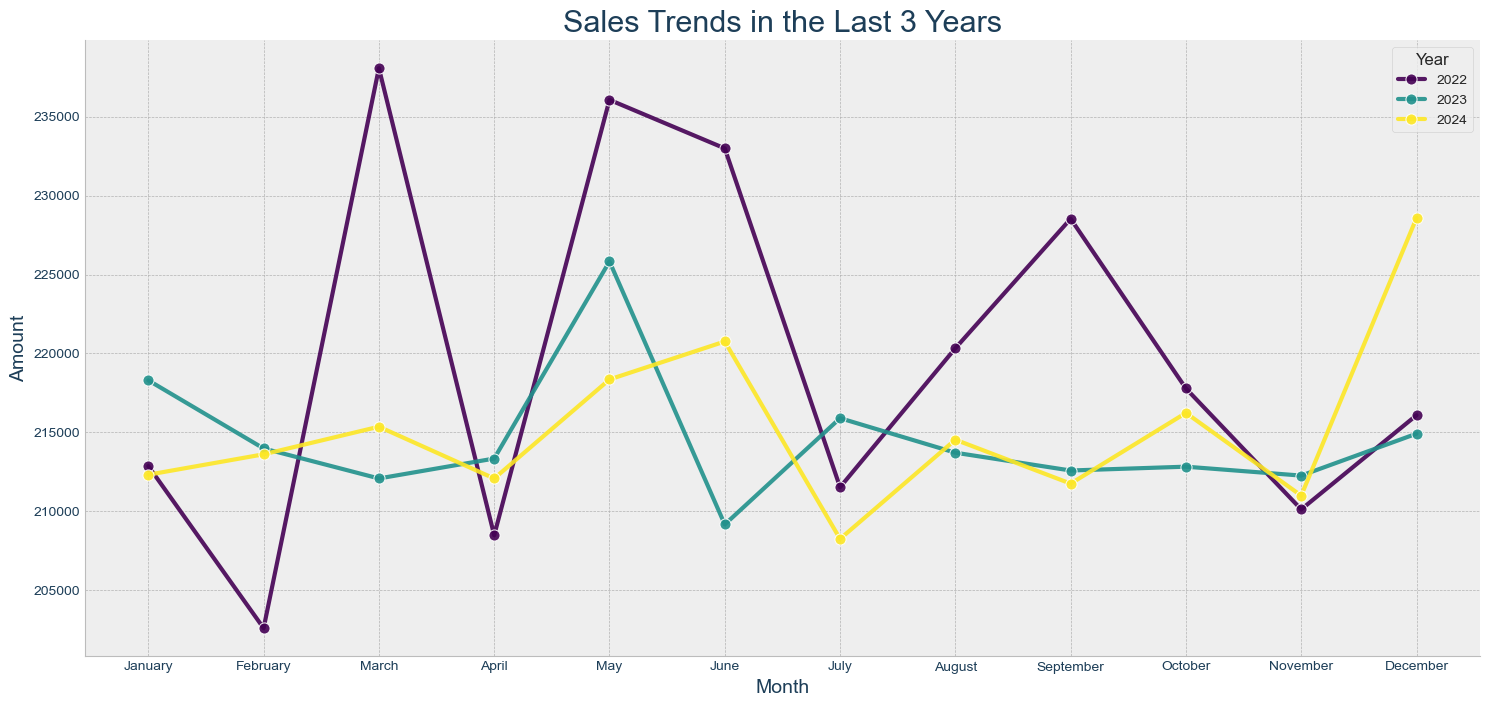

In [207]:
# Visualize sales trends in the last 3 years

plt.style.use('bmh')
plt.figure(figsize=(18, 8))

graphic_t = sns.lineplot(x="month_name", y="amount",hue="year",data=df_extra,marker="o",
                         linewidth=3,markersize=8, alpha=0.9 ,palette="viridis")

graphic_t.set_title("Sales Trends in the Last 3 Years",fontsize=22,color="#1d3e58")


# Set colors and size
graphic_t.set_xlabel("Month", fontsize=14, color="#1d3e58")
graphic_t.set_ylabel("Amount", fontsize=14, color="#1d3e58")

graphic_t.yaxis.label.set_color("#1d3e58")
graphic_t.xaxis.label.set_color("#1d3e58")
graphic_t.tick_params(axis='both', colors="#1d3e58")


plt.legend(title="Year", title_fontsize=12, fontsize=10)

sns.despine()

plt.show()

<div style="text-align:center;">
<h3><span style="color:#D4AF37">Insights :<br></span></h3>
<font color="#777777">
This chart tracks sales performance over a three-year period, highlighting significant volatility in 2022 with major peaks in March and May. <br>
While 2023 shows more stabilized growth, 2024 concludes with a sharp upward trend in December, indicating a strong year-end performance.<br> 
Overall, the data suggests evolving seasonal dynamics and a positive growth trajectory moving into the most recent months.
</font>
</div>

<div style="text-align:center;">

<hr style="
    border: 0;
    height: 2px;
    background-color:#777777;
    width:60%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">



<div style="text-align:center;">
<hr style="border: 0;height: 2px;background-color:#777777;width:60%;margin:25px auto;box-shadow: 0 2px 6px rgba(0,0,0,0.25);">
</div>
<div style="text-align:center;">
<h2 style="color:#C9B037;"> LINEPLOT – "Sales Trends in the Last 3 Years" </h2>
<h3><span style="color:#003366">Script on Power BI:<br></span></h3>
</div>
<div style="text-align:left; color:#777777; font-family:monospace; margin-left:20%;">
import pandas as pd<br> 
import matplotlib.pyplot as plt<br> 
import seaborn as sns<br><br>

df_extra = dataset[["year","month_name","amount"]]<br><br>

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]<br><br>
df_extra["month_name"] = pd.Categorical(df_extra["month_name"],categories=month_order, ordered=True)<br><br>

plt.style.use('bmh')<br> plt.figure(figsize=(18, 8))<br><br>

graphic_t = sns.lineplot(x="month_name", y="amount", hue="year", data=df_extra, marker="o",linewidth=3, markersize=8, alpha=0.9, palette="viridis")<br><br>

graphic_t.set_title("Sales Trends in the Last 3 Years", fontsize=22, color="#1d3e58")<br><br>

graphic_t.set_xlabel("Month", fontsize=14, color="#1d3e58")<br> graphic_t.set_ylabel("Amount", fontsize=14, color="#1d3e58")<br><br>

graphic_t.yaxis.label.set_color("#1d3e58")<br> graphic_t.xaxis.label.set_color("#1d3e58")<br> graphic_t.tick_params(axis='both', colors="#1d3e58")<br><br>

plt.legend(title="Year", title_fontsize=12, fontsize=10)<br><br>
sns.despine()<br><br>
plt.show()<br>
</div>
<div style="text-align:center;">
<hr style="border: 0;height: 2px;background-color:#777777;width:60%;margin:25px auto;box-shadow: 0 2px 6px rgba(0,0,0,0.25);">
</div>

<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">
<hr style="
    border: 0;
    height: 2px;
    background-color:#003366;
    width:80%;
    margin:25px auto;
    box-shadow: 0 2px 6px rgba(0,0,0,0.25);
">


<div style="text-align:center;">